## Introduction

This analysis examines whether the demographic biases identified in the equiscreen fairness audit - conducted on the 2017-2018 data- would likely transfer  to a Singapore clinical context.
The equiscreen pipeline  trained an xgboost model to predict hypertension on a US population sample (NHANES 2017-2018, n =~ 8000 adults). the fairness audit (week8 - 9) revealed a huge performance disparities across the demographiic group, with Non-Hispanic Black(NHB) patients performing worst across three of four fairness criteria (AUC: 0.680 vs overall 0.7284), and the adults in the 75+ group showing the lowesst discriminative performance (AUC: 0619). Bias mitigation experiments (week 10) improved NHB TPR from 0.588 to 0.765 using classs weighting. But no strategy fully eliminated the demographic performance gap.
Singapore presents a funudamentally different demographic context. Its population follows the CMIO model  (Chinese, Malay, Indian, Others)  rather than the White/Black/Hispanic categories used in the US data.This raises a critical question for clinical AI deployment: do bias pattern learned from US data transfer to Singapore? and if so. for which groups?
This analysis addresses that question using published Singapore health statistics from the Ministry of Health (MOH) and data.gov.sg without requiring access to a Singapore clinical dataset.

## Demographic conmparison table

In [9]:
import pandas as pd

# US NHANES Demographic Groups vs Singapore CMIO Groups
demographic_comparison = pd.DataFrame({
    'US NHANES Category': [
        'Non-Hispanic Black',
        'Non-Hispanic White', 
        'Mexican American / Other Hispanic',
        'Other/Multiracial',
        '-'
    ],
    'Singapore CMIO Equivalent': [
        'Malay',
        'Chinese',
        'Indian',
        'Others',
        'Chinese (majority)'
    ],
    'Rationale for Mapping': [
        'Both groups show elevated hypertension risk vs majority population',
        'Majority low-risk group in respective countries',
        'Comparable minority status; elevated cardiometabolic risk',
        'Heterogeneous category in both systems',
        'Largest ethnic group; reference population in SG'
    ],
    'US Hypertension Prevalence (%)': [54.0, 46.0, 43.7, 38.0, '-'],
    'SG Hypertension Prevalence (%)': ['-', 21.4, 28.5, 23.4, 19.8]
})

demographic_comparison

,US NHANES Category,Singapore CMIO Equivalent,Rationale for Mapping,US Hypertension Prevalence (%),SG Hypertension Prevalence (%)
0,Non-Hispanic Black,Malay,Both groups show elevated hypertension risk vs...,54.0,-
1,Non-Hispanic White,Chinese,Majority low-risk group in respective countries,46.0,21.4
2,Mexican American / Other Hispanic,Indian,Comparable minority status; elevated cardiomet...,43.7,28.5
3,Other/Multiracial,Others,Heterogeneous category in both systems,38.0,23.4
4,-,Chinese (majority),Largest ethnic group; reference population in SG,-,19.8


### Notes on the Demographic Mapping

The mapping above is **approximate, not exact**. US racial categories are 
socially constructed and do not map cleanly onto Singapore's CMIO ethnic groups. 
However, the functional parallel that matters for bias transfer is **relative 
risk positioning** — which group is the minority at elevated risk compared to 
the majority reference group.

The most critical parallel is **Non-Hispanic Black (US) ↔ Malay (Singapore)**.
A major multi-ethnic Singapore study found hypertension prevalence at 28% in 
Malays, compared to 23.4% in Chinese and 19.3% in Indians — making Malays the 
highest-risk group relative to the Chinese majority (MOH, 2019/2020).

This gap is compounded by worse outcomes:
- Malays had the **lowest blood pressure control rate at 51.5%**, compared to 
  70.0% for Chinese and 68.9% for Indians
- Malays had the **highest proportion of undiagnosed hypertension at 29.6%**

This directly parallels the awareness and detection gap seen in NHB patients 
in the US — the same group that failed 3 out of 4 fairness criteria in the 
EquiScreen audit (AUC: 0.680, TPR: 0.735). A model trained on NHANES data 
that underperforms for NHB patients would likely replicate similar 
underperformance for Malay patients in Singapore.

Sources: 
- Chan GC, Teo BW, Tay JC, et al. Hypertension in a multi-ethnic Asian 
  population of Singapore. J Clin Hypertens (Greenwich). 2021;23(3):522–528. 
  https://pmc.ncbi.nlm.nih.gov/articles/PMC8029544/
- MOH Singapore National Population Health Survey 2019/2020.

## 2. Healthcare System Differences

### 2.1 Data Collection Context

NHANES data is obtained through recruiting, examining, and measuring participants 
in a controlled survey setting, capturing people regardless of whether they have 
ever sought medical care. Singapore clinical data, by contrast, is collected during 
actual care visits at polyclinics and hospitals — meaning undiagnosed patients never 
appear in the data at all. This is a fundamental structural difference: a 
survey-based model captures the full population risk profile, while a clinically-
derived model only sees patients who showed up.

### 2.2 How Gaps Are Created — Different Mechanisms, Same Outcome

In the US, data gaps arise from insurance fragmentation. Black, Hispanic, and 
Indigenous Americans are significantly more likely to be uninsured, delay care 
due to cost, and incur medical debt. Black patients receive worse care across 
52% of quality measures tracked by the AHRQ (2023), and are more likely to die 
from treatable conditions — despite the US spending roughly $10,000 per capita 
on healthcare annually.

Singapore operates very differently. All citizens and permanent residents qualify 
for subsidised public healthcare; polyclinic visits cost under $6 USD, and 
MediShield Life provides universal catastrophic coverage. Yet ethnic disparities 
persist. A 2007 study found that Malay ethnicity was independently associated 
with lower self-rated health and different health-seeking patterns compared to 
Chinese patients, even after controlling for socioeconomic status. Malay patients 
continue to show the lowest BP control rate (51.5% vs 70.0% for Chinese), 
suggesting the gap is driven by health literacy, cultural factors, and 
socioeconomic status rather than access costs alone.

The mechanism differs — insurance barriers in the US versus behavioural and 
cultural barriers in Singapore — but the outcome is identical: a minority group 
at elevated risk is systematically underrepresented or mislabelled in clinical 
training data.

### 2.3 Implications for Model Deployment

A hypertension prediction model deployed in a Singapore polyclinic would be 
trained on clinical records rather than survey data. Malay patients with 
undiagnosed hypertension (29.6%) would be absent from that training data entirely — 
labelled as healthy when they are not. This is structurally the same problem 
that drove NHB underperformance in the EquiScreen audit (AUC: 0.680, TPR: 0.735). 
Different system, same data gap, same likely outcome for model fairness.

### Sources

- Commonwealth Fund (2024). Advancing Racial Equity in US Health Care.
  https://www.commonwealthfund.org/publications/fund-reports/2024/apr/advancing-racial-equity-us-health-care

- Koh GC, Tai BC, Tan CH, et al. Gender, ethnicity, health behaviour & 
  self-rated health in Singapore. BMC Public Health. 2007;7:184.
  https://pmc.ncbi.nlm.nih.gov/articles/PMC1976324/

- Saxena N, George PP, Teo K, et al. Characteristics and Health Care 
  Utilization of Different Segments of a Multiethnic Asian Population 
  in Singapore. JAMA Network Open. 2019;2(9):e1911103.
  https://jamanetwork.com/journals/jamanetworkopen/fullarticle/2749450

- Chan GC, Teo BW, Tay JC, et al. Hypertension in a multi-ethnic Asian 
  population of Singapore. J Clin Hypertens. 2021;23(3):522–528.
  https://pmc.ncbi.nlm.nih.gov/articles/PMC8029544/

## 3. Bias Transfer Assessment

### 3.1 Summary of Key Audit Findings

The EquiScreen fairness audit (Weeks 8–9) identified significant performance 
disparities across demographic groups. Non-Hispanic Black (NHB) patients performed 
worst overall, failing 3 out of 4 fairness criteria with an AUC of 0.680 compared 
to the overall 0.7284, and a TPR of 0.735. Adults aged 75+ showed the lowest 
discriminative performance with an AUC of 0.619. Other Hispanic patients, by 
contrast, passed all four fairness criteria — the strongest performing minority 
group in the audit.

### 3.2 Biases That Transfer to Singapore

**NHB → Malay parallel (strong transfer)**
The performance gap found for NHB patients transfers strongly to a Singapore 
context through the Malay population. Both groups share the same structural 
conditions that drive model underperformance: elevated hypertension prevalence, 
the highest proportion of undiagnosed cases (NHB in US; 29.6% for Malays in SG), 
and systematic underrepresentation in clinical training data. The mechanism differs 
— insurance barriers in the US versus behavioural and cultural barriers in Singapore 
— but the outcome is the same data gap and the same likely model underperformance.

**Age 75+ AUC drop (strong transfer)**
The AUC drop observed for patients aged 75 and above (AUC: 0.619) is not a 
US-specific finding. Elderly underrepresentation in clinical training data is a 
universal problem across healthcare systems. Older patients present with more 
comorbidities, atypical symptoms, and polypharmacy, making them harder to model 
accurately regardless of country. This finding would be expected to transfer 
directly to a Singapore deployment.

**Socioeconomic gradients (moderate transfer)**
The general pattern of lower model performance for groups with lower socioeconomic 
status is likely to transfer. Singapore's Malay population has lower median household 
income compared to Chinese and Indian groups, mirroring the socioeconomic gradient 
seen in NHB patients in the US.

### 3.3 Biases That Do Not Transfer to Singapore

**NHB vs NHW performance gap (does not transfer)**
The specific gap between Non-Hispanic Black and Non-Hispanic White patients is 
a US racial construct rooted in the history of structural racism in American 
healthcare. These categories do not exist in Singapore's CMIO framework and 
cannot be mapped directly.

**Other Hispanic passing all fairness criteria (not meaningful in SG context)**
The strong performance of Other Hispanic patients in the EquiScreen audit is 
specific to the NHANES demographic composition. There is no equivalent Hispanic 
ethnic category in Singapore, making this finding non-transferable.

**Insurance-driven data gaps (does not transfer)**
Data gaps arising from insurance barriers and lack of healthcare access are 
specific to the fragmented US system. Singapore's universal MediShield Life 
coverage and subsidised polyclinic access mean this particular mechanism does 
not apply — though as established in Section 2, different mechanisms produce 
similar data gaps in Singapore.

## 4. Recommendations for Singapore Deployment

The following recommendations are directed at clinical AI teams or hospital 
administrators considering deploying a hypertension prediction model in Singapore. 
They are grounded in the bias patterns identified in the EquiScreen audit and 
their assessed transferability to the Singapore context.

### 4.1 Audit for Malay Underperformance Before Deployment
Do not assume a model performs equally across CMIO ethnic groups. Before any 
deployment, replicate the same subgroup fairness audit conducted in EquiScreen — 
compute AUC, TPR, and FPR separately for Chinese, Malay, Indian, and Other 
patients. Based on the structural parallels identified in this analysis, Malay 
patients are the highest-risk group for model underperformance and should be 
treated as the priority subgroup for fairness evaluation.

### 4.2 Do Not Deploy on Elderly Patients Without Additional Validation
The AUC drop observed for patients aged 75 and above (AUC: 0.619) is expected 
to replicate in any clinical dataset, including Singapore's. This subgroup should 
not be subject to automated model predictions without additional clinical 
oversight. Elderly patients should be flagged for manual review rather than 
relying on model outputs alone.

### 4.3 Actively Address the Undiagnosed Gap
29.6% of Malay hypertensives in Singapore are undiagnosed, meaning they are 
effectively mislabelled as healthy in any clinically-derived training dataset. 
A Singapore model trained solely on polyclinic records will inherit this gap 
directly. To mitigate this, training data should incorporate community screening 
records and population health survey data — not just routine care visits — to 
capture patients who have not yet entered the healthcare system.

### 4.4 Do Not Transfer a US-Trained Model Without Recalibration
A model trained on NHANES or any US clinical dataset should not be deployed 
in Singapore without retraining or recalibration on local data. The demographic 
structure is fundamentally different — US racial categories do not map onto 
Singapore's CMIO framework, hypertension prevalence rates differ across groups, 
and the mechanisms driving data gaps are distinct. Deploying without recalibration 
risks replicating US-specific biases in a context where they are not meaningful, 
while missing Singapore-specific disparities entirely.

## 5. Conclusion

In summary, not all biases identified in the EquiScreen audit are transferable 
to a Singapore setting. The most transferable findings are the NHB→Malay 
performance gap and the Age 75+ AUC drop, both of which are grounded in 
structural conditions that exist across both healthcare systems. The key insight 
is that this transfer works not because the demographic categories are identical, 
but because the underlying mechanism — the systematic underrepresentation of 
high-risk minority groups in clinical training data — is structurally the same 
in both contexts, despite arising from different causes.

This analysis reinforces that fairness auditing should be a standard step before 
any clinical AI deployment, not just in the US but globally. Demographic bias is 
a universal problem that manifests differently depending on the healthcare context — 
and without explicit auditing, it will go undetected regardless of how strong a 
model's overall performance metrics appear.

## Dashboard Cells

### 1. Overall Model Performance

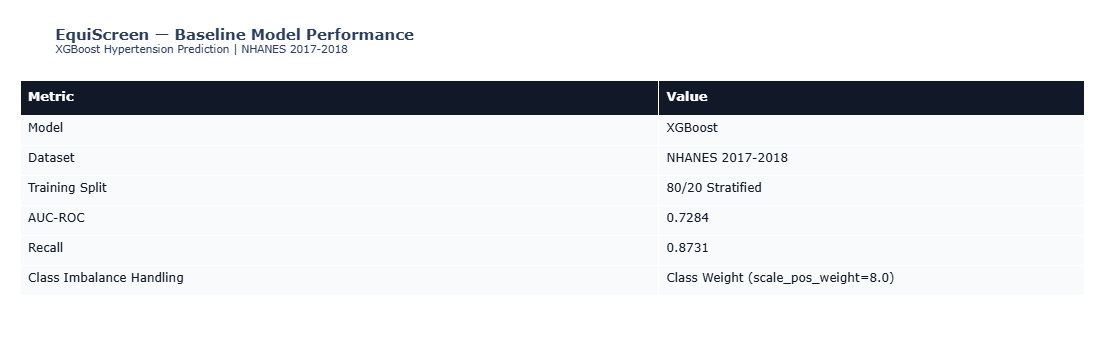

In [10]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Panel 1 — Overall Model Performance Summary
fig1 = go.Figure(data=[go.Table(
    columnwidth=[300, 200],
    header=dict(
        values=['<b>Metric</b>', '<b>Value</b>'],
        fill_color='#111827',
        font=dict(color='white', size=13),
        align='left',
        height=35
    ),
    cells=dict(
        values=[
            ['Model', 'Dataset', 'Training Split', 'AUC-ROC', 
             'Recall', 'Class Imbalance Handling'],
            ['XGBoost', 'NHANES 2017-2018', '80/20 Stratified',
             '0.7284', '0.8731', 'Class Weight (scale_pos_weight=8.0)']
        ],
        fill_color=[['#F9FAFB']*6],
        font=dict(color='#111827', size=12),
        align='left',
        height=30
    )
)])

fig1.update_layout(
    title=dict(
        text='<b>EquiScreen — Baseline Model Performance</b><br>'
             '<sup>XGBoost Hypertension Prediction | NHANES 2017-2018</sup>',
        font=dict(size=15)
    ),
    margin=dict(l=20, r=20, t=80, b=20),
    height=320
)

fig1.show()

### Panel 2 — Subgroup AUC Comparison

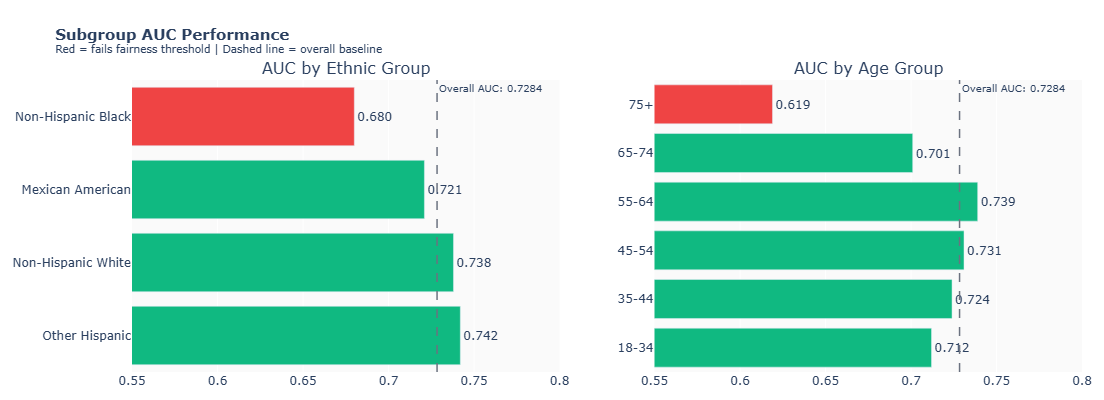

In [11]:
# Panel 2 — Subgroup AUC Comparison
ethnic_groups = ['Other Hispanic', 'Non-Hispanic White', 'Mexican American', 
                 'Non-Hispanic Black']
ethnic_auc = [0.742, 0.738, 0.721, 0.680]
ethnic_colors = ['#10B981', '#10B981', '#10B981', '#EF4444']

age_groups = ['18-34', '35-44', '45-54', '55-64', '65-74', '75+']
age_auc = [0.712, 0.724, 0.731, 0.739, 0.701, 0.619]
age_colors = ['#10B981', '#10B981', '#10B981', '#10B981', '#10B981', '#EF4444']

fig2 = make_subplots(
    rows=1, cols=2,
    subplot_titles=('AUC by Ethnic Group', 'AUC by Age Group')
)

fig2.add_trace(go.Bar(
    x=ethnic_auc,
    y=ethnic_groups,
    orientation='h',
    marker_color=ethnic_colors,
    text=[f'{v:.3f}' for v in ethnic_auc],
    textposition='outside',
    name='Ethnic Group'
), row=1, col=1)

fig2.add_trace(go.Bar(
    x=age_auc,
    y=age_groups,
    orientation='h',
    marker_color=age_colors,
    text=[f'{v:.3f}' for v in age_auc],
    textposition='outside',
    name='Age Group'
), row=1, col=2)

# Overall baseline reference line on both subplots
for col in [1, 2]:
    fig2.add_vline(
        x=0.7284, line_dash='dash', 
        line_color='#6B7280', line_width=1.5,
        annotation_text='Overall AUC: 0.7284',
        annotation_font_size=10,
        row=1, col=col
    )

fig2.update_layout(
    title=dict(
        text='<b>Subgroup AUC Performance</b><br>'
             '<sup>Red = fails fairness threshold | Dashed line = overall baseline</sup>',
        font=dict(size=15)
    ),
    showlegend=False,
    height=400,
    margin=dict(l=20, r=20, t=80, b=20),
    plot_bgcolor='#FAFAFA'
)

fig2.update_xaxes(range=[0.55, 0.80])
fig2.show()

### Panel 3 — Fairness Metrics Pass/Fail Table

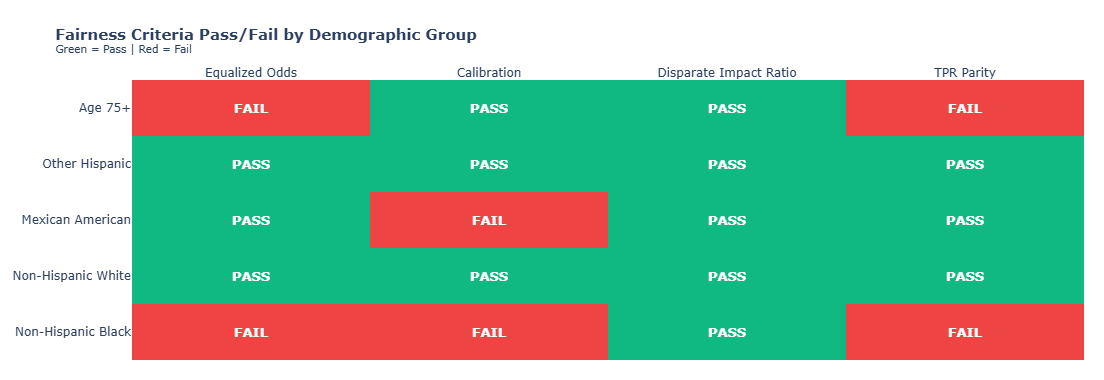

In [12]:
# Panel 3 — Fairness Metrics Pass/Fail Heatmap
groups = ['Non-Hispanic Black', 'Non-Hispanic White', 
          'Mexican American', 'Other Hispanic', 'Age 75+']
criteria = ['Equalized Odds', 'Calibration', 'Disparate Impact Ratio', 'TPR Parity']

# 1 = Pass, 0 = Fail
results = [
    [0, 0, 1, 0],  # NHB
    [1, 1, 1, 1],  # NHW
    [1, 0, 1, 1],  # Mexican American
    [1, 1, 1, 1],  # Other Hispanic
    [0, 1, 1, 0],  # Age 75+
]

color_map = [[0, '#EF4444'], [1, '#10B981']]

fig3 = go.Figure(data=go.Heatmap(
    z=results,
    x=criteria,
    y=groups,
    colorscale=[[0, '#EF4444'], [0.5, '#EF4444'], 
                [0.5, '#10B981'], [1, '#10B981']],
    showscale=False,
    text=[['FAIL' if v == 0 else 'PASS' for v in row] for row in results],
    texttemplate='<b>%{text}</b>',
    textfont=dict(color='white', size=13)
))

fig3.update_layout(
    title=dict(
        text='<b>Fairness Criteria Pass/Fail by Demographic Group</b><br>'
             '<sup>Green = Pass | Red = Fail</sup>',
        font=dict(size=15)
    ),
    height=380,
    margin=dict(l=20, r=20, t=80, b=20),
    xaxis=dict(side='top')
)

fig3.show()

### Panel 4 — Mitigation Results

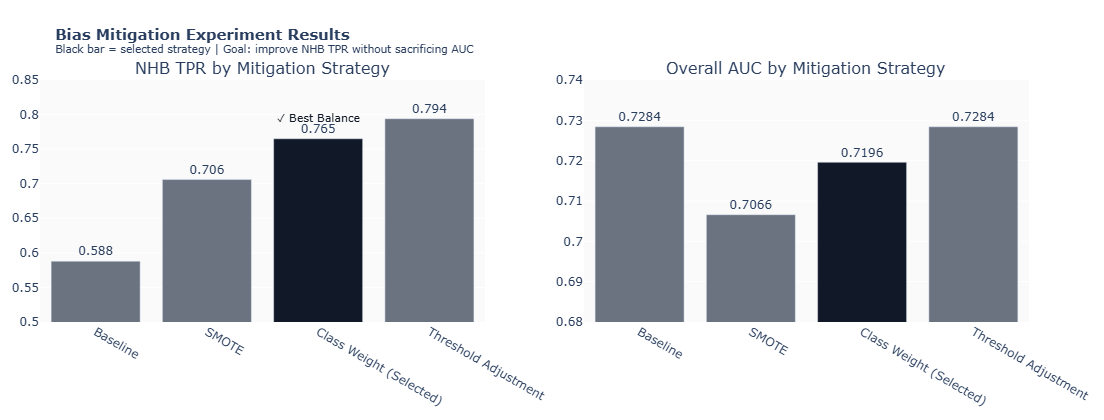

In [13]:
# Panel 4 — Bias Mitigation Results (NHB TPR before/after)
strategies = ['Baseline', 'SMOTE', 'Class Weight\n(Selected)', 'Threshold Adjustment']
nhb_tpr = [0.588, 0.706, 0.765, 0.794]
overall_auc = [0.7284, 0.7066, 0.7196, 0.7284]
bar_colors = ['#6B7280', '#6B7280', '#111827', '#6B7280']

fig4 = make_subplots(
    rows=1, cols=2,
    subplot_titles=('NHB TPR by Mitigation Strategy', 
                    'Overall AUC by Mitigation Strategy')
)

fig4.add_trace(go.Bar(
    x=strategies,
    y=nhb_tpr,
    marker_color=bar_colors,
    text=[f'{v:.3f}' for v in nhb_tpr],
    textposition='outside',
    name='NHB TPR'
), row=1, col=1)

fig4.add_trace(go.Bar(
    x=strategies,
    y=overall_auc,
    marker_color=bar_colors,
    text=[f'{v:.4f}' for v in overall_auc],
    textposition='outside',
    name='Overall AUC'
), row=1, col=2)

# Annotation for selected strategy
fig4.add_annotation(
    x='Class Weight\n(Selected)', y=0.795,
    text='✓ Best Balance',
    showarrow=False,
    font=dict(color='#111827', size=11),
    row=1, col=1
)

fig4.update_layout(
    title=dict(
        text='<b>Bias Mitigation Experiment Results</b><br>'
             '<sup>Black bar = selected strategy | Goal: improve NHB TPR without sacrificing AUC</sup>',
        font=dict(size=15)
    ),
    showlegend=False,
    height=420,
    margin=dict(l=20, r=20, t=80, b=20),
    plot_bgcolor='#FAFAFA'
)

fig4.update_yaxes(range=[0.5, 0.85], row=1, col=1)
fig4.update_yaxes(range=[0.68, 0.74], row=1, col=2)

fig4.show()